Target Run ID: 20251130_153500
Output Directory: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500

--- Organizing Data for Thesis ---
Processing A_OH_plus_others...
  [WARN] 4 missing values found in target variables after merge.
  -> Saved merged data: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/ThesisData_A_OH_plus_others_MDS_Targets.csv
Processing B_FP_plus_others...
  [WARN] 4 missing values found in target variables after merge.
  -> Saved merged data: /Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127/Thesis_Figures/run_20251130_153500/ThesisData_B_FP_plus_others_MDS_Targets.csv

--- Generating Appendix Figures ---

--- Generating Main Text Figures ---


TypeError: Colorbar.set_label() missing 1 required positional argument: 'label'

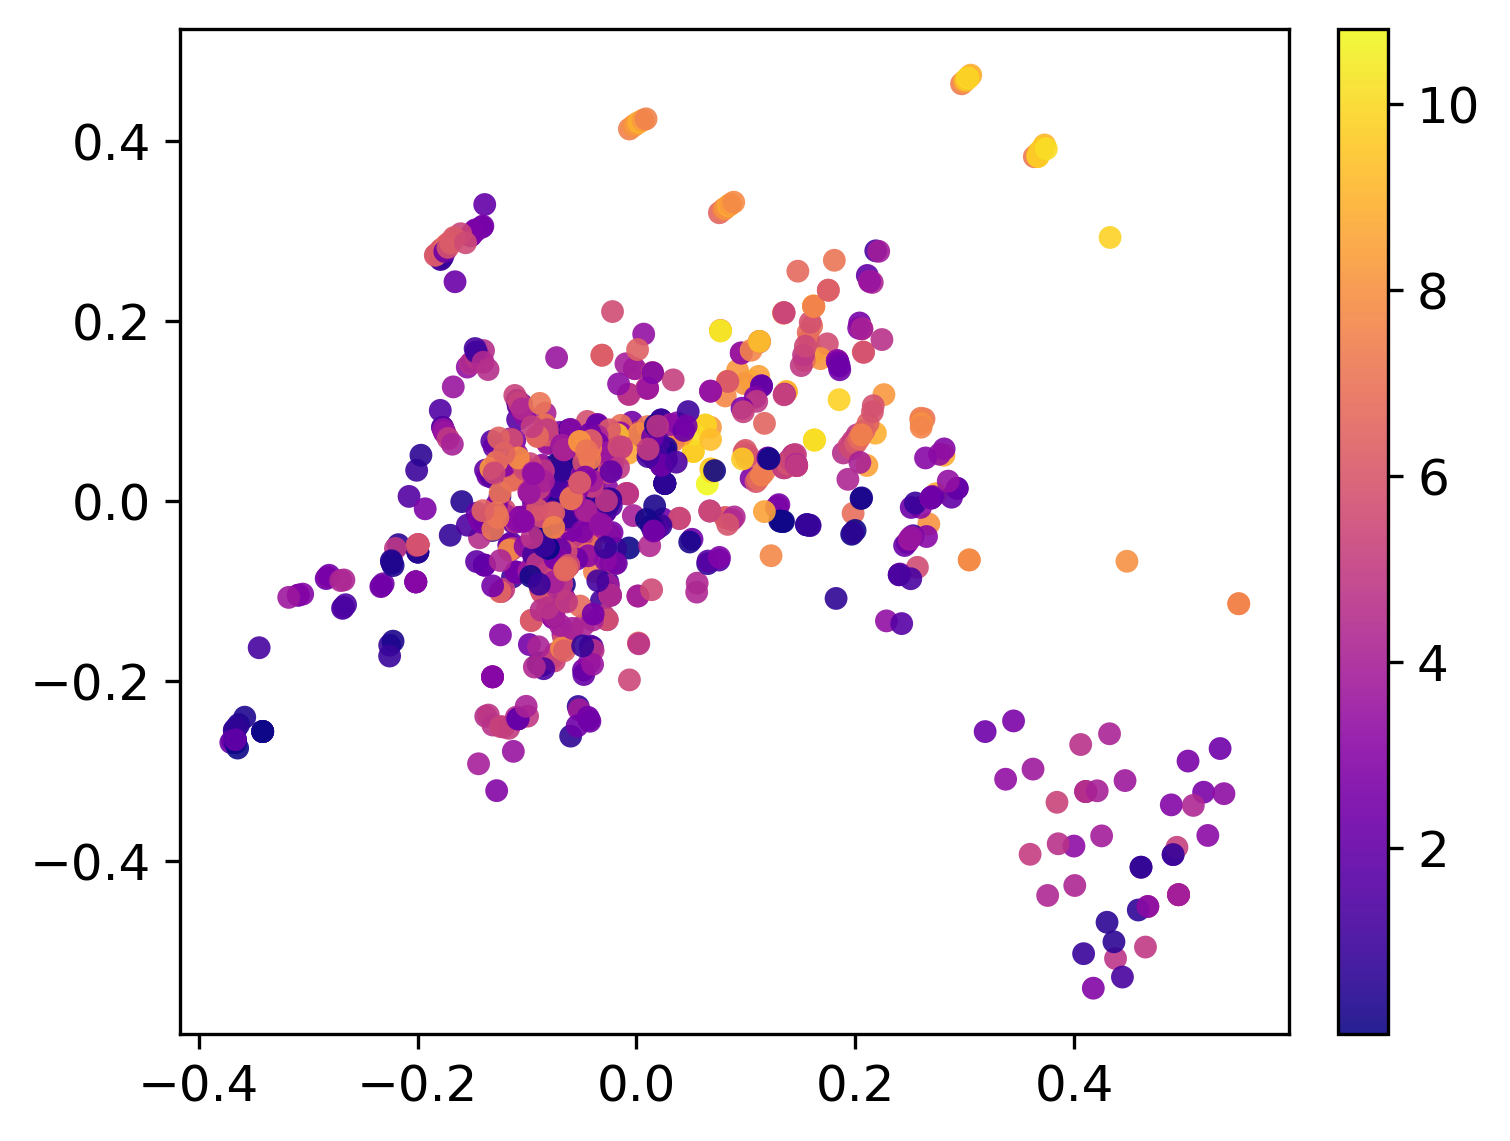

In [5]:
# STEP3.2_05_thesis_plotting_pipeline_v2.py
#
# 変更点: 目的変数（PCE等）の取得元を「前処理済みファイル」から「元データ(DataMerge...)」に変更
#

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ==========================================
# 1. 設定 (Configuration)
# ==========================================

RUN_ID = "20251130_153500"  # Rで計算したID
ROOT_BASE = "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/cal_cluster_No/20251026_under_25clusters_program_and_result/for_checking_20251127"

# パス定義
SUB_DIR = os.path.join(ROOT_BASE, "sub", "02_mds_STEP3.2_signlessCorr", f"run_{RUN_ID}")
INPUT_DATA_DIR = os.path.join(ROOT_BASE, "data", "for_MDS_STEP2")
OUTPUT_FIG_DIR = os.path.join(ROOT_BASE, "Thesis_Figures", f"run_{RUN_ID}")

os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

# プロットスタイル
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']
plt.rcParams['font.size'] = 14
plt.rcParams['figure.dpi'] = 300

# データセット定義
DATASETS_VARS = ["OH", "FP"]
DATASETS_SAMPLES = ["A_OH_plus_others", "B_FP_plus_others"] # 必要に応じてC, Dも追加可

# ★正確な目的変数名★
TARGET_VARS = ["Jsc", "Voc", "FF", "PCEmax"]

print(f"Target Run ID: {RUN_ID}")
print(f"Output Directory: {OUTPUT_FIG_DIR}")

# ==========================================
# 2. ヘルパー関数
# ==========================================

def load_mds_coords(unit, dataset, mode="linear_top3"):
    """R出力のMDS座標を読み込む"""
    fname = f"MDScoords_{mode}_{unit}_{dataset}_{RUN_ID}.csv"
    path = os.path.join(SUB_DIR, unit, dataset, fname)
    if not os.path.exists(path):
        print(f"[WARN] MDS file not found: {path}")
        return None
    return pd.read_csv(path, index_col=0)

def load_raw_targets(dataset_key):
    """
    元データ（DataMerge...）から目的変数を読み込む
    dataset_key に 'OH' が含まれていれば OH系ファイル、'FP' なら FP系ファイルを読み込む
    """
    
    # ★ここを修正：元データのファイル名を指定
    if "OH" in dataset_key:
        fname = "DataMerge20211220oh_20250717_OH_delSMILES.csv"
    elif "FP" in dataset_key:
        fname = "DataMerge20211220FP_20250715.csv"
    else:
        print(f"[WARN] Unknown dataset type: {dataset_key}")
        return None

    path = os.path.join(INPUT_DATA_DIR, fname)
    if not os.path.exists(path):
        print(f"[ERROR] Original data file not found: {path}")
        print(f"Please place the file in: {INPUT_DATA_DIR}")
        return None
    
    # 読み込み（1列目をIDとして扱う: index_col=0）
    # ※もしID列が1列目でない場合は index_col=None にして別途指定が必要
    try:
        df = pd.read_csv(path, index_col=0)
    except Exception as e:
        print(f"[ERROR] Failed to read csv: {e}")
        return None

    return df

# ==========================================
# 3. データ整理 & 保存 (Data Organization)
# ==========================================
print("\n--- Organizing Data for Thesis ---")

merged_data = {}

for ds in DATASETS_SAMPLES:
    print(f"Processing {ds}...")
    
    # 1. MDS座標 (計算済みの地図)
    df_mds = load_mds_coords("samples", ds, mode="linear_top3")
    
    # 2. 元データ (目的変数を持つ巨大な表)
    df_raw = load_raw_targets(ds)
    
    if df_mds is not None and df_raw is not None:
        # 列名の空白削除 (" PCEmax" -> "PCEmax")
        df_raw.columns = df_raw.columns.str.strip()
        
        # 必要な列があるかチェック
        missing = [t for t in TARGET_VARS if t not in df_raw.columns]
        if missing:
            print(f"  [ERROR] Columns not found in raw data: {missing}")
            print(f"  Available columns (sample): {df_raw.columns[:5].tolist()} ...")
            continue
            
        # 3. 結合 (MDSのIDを基準に、元データから4列だけくっつける)
        # left_join: MDSにあるサンプルだけを残す
        df_merge = df_mds.join(df_raw[TARGET_VARS], how='left')
        
        # 4. 欠損チェック (元データにIDが見つからなかった場合など)
        nan_count = df_merge[TARGET_VARS].isna().sum().sum()
        if nan_count > 0:
            print(f"  [WARN] {nan_count} missing values found in target variables after merge.")
            
        save_path = os.path.join(OUTPUT_FIG_DIR, f"ThesisData_{ds}_MDS_Targets.csv")
        df_merge.to_csv(save_path)
        merged_data[ds] = df_merge
        print(f"  -> Saved merged data: {save_path}")

# ==========================================
# 4. 図表作成: Appendix用
# ==========================================
# （Scree Plot等は元データ不要なので、前回のコードと同じロジックで動きます）
# 省略せず記述します

print("\n--- Generating Appendix Figures ---")

def plot_scree(dataset, unit="variables"):
    path = os.path.join(SUB_DIR, unit, dataset, f"MDS_eigen_contributions_{unit}_{dataset}_{RUN_ID}.csv")
    if not os.path.exists(path): return
    df_eig = pd.read_csv(path)
    df_plot = df_eig.head(30).copy()
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.bar(df_plot['axis'], df_plot['percent']*100, color='#4c72b0', alpha=0.8, label='Individual')
    ax1.set_xlabel('Dimension')
    ax1.set_ylabel('Variance Explained (%)', color='#4c72b0')
    
    ax2 = ax1.twinx()
    ax2.plot(df_plot['axis'], df_plot['cum_percent']*100, color='#c44e52', marker='o', linewidth=2, label='Cumulative')
    ax2.set_ylabel('Cumulative Variance (%)', color='#c44e52')
    ax2.axhline(80, color='gray', linestyle='--', alpha=0.5)
    
    plt.title(f"Scree Plot: {dataset} ({unit})")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"Appendix_Scree_{dataset}.png"))
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"Appendix_Scree_{dataset}.pdf"))
    plt.close()

for ds in DATASETS_VARS:
    plot_scree(ds, "variables")

def plot_linear_vs_nonlinear(dataset, unit="variables"):
    df_lin = load_mds_coords(unit, dataset, "linear_top3")
    df_non = load_mds_coords(unit, dataset, "nonlinear_top3")
    if df_lin is None or df_non is None: return

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].scatter(df_lin.iloc[:,0], df_lin.iloc[:,1], alpha=0.6, c='steelblue', s=30)
    axes[0].set_title("(a) Linear MDS (PCoA)", fontweight="bold")
    axes[1].scatter(df_non.iloc[:,0], df_non.iloc[:,1], alpha=0.6, c='darkorange', s=30)
    axes[1].set_title("(b) Nonlinear MDS (isoMDS)", fontweight="bold")
    plt.suptitle(f"Comparison of MDS Methods: {dataset}", y=0.98)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"Appendix_Lin_vs_Nonlin_{dataset}.png"))
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"Appendix_Lin_vs_Nonlin_{dataset}.pdf"))
    plt.close()

for ds in DATASETS_VARS:
    plot_linear_vs_nonlinear(ds, "variables")

# ==========================================
# 5. 図表作成: Main Text用 (Results)
# ==========================================
print("\n--- Generating Main Text Figures ---")

# (Fig 1: Variables Map)
def plot_variables_map(dataset):
    df = load_mds_coords("variables", dataset, "linear_top3")
    if df is None: return
    plt.figure(figsize=(7, 7))
    plt.scatter(df.iloc[:,0], df.iloc[:,1], alpha=0.7, c='teal', s=40, edgecolors='white')
    plt.title(f"Material Space Structure: {dataset}", fontweight="bold")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"Main_VarMap_{dataset}.png"))
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"Main_VarMap_{dataset}.pdf"))
    plt.close()

for ds in DATASETS_VARS:
    plot_variables_map(ds)

# (Fig 2: Samples Superimpose - 2x2 Grid)
def plot_performance_grid(dataset):
    if dataset not in merged_data: return
    df = merged_data[dataset]

    # 2x2 のグリッドを作成
    fig = plt.figure(figsize=(12, 10))
    gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3) # 間隔を少し調整

    # 配置場所を固定 (行, 列)
    # (a) PCE -> 左上 (0,0)
    # (b) Jsc -> 右上 (0,1)
    # (c) Voc -> 左下 (1,0)
    # (d) FF  -> 右下 (1,1)

    # 設定リスト: [変数名, ラベル, 位置(row, col)]
    plot_settings = [
        ("PCEmax", "(a) PCE (%)",        0, 0),
        ("Jsc",    "(b) Jsc (mA/cm²)",   0, 1),
        ("Voc",    "(c) Voc (V)",        1, 0),
        ("FF",     "(d) FF",             1, 1)
    ]

    # 統一カラーマップ (plasma: 黄=高, 紫=低)
    # ※ 'jet' (虹色) よりも 'plasma' や 'viridis' の方が論文では推奨されます
    common_cmap = "plasma"

    for target, label, r, c in plot_settings:
        ax = fig.add_subplot(gs[r, c])

        if target not in df.columns:
            continue

        # 欠損除去
        subset = df.dropna(subset=[target])

        # 散布図作成
        sc = ax.scatter(subset['V1'], subset['V2'], c=subset[target], 
                        cmap=common_cmap, s=30, alpha=0.9, edgecolors='none')

        # カラーバー (各グラフの右側に配置)
        cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label()
#         cbar.set_label(target, rotation=270, labelpad=15)

        # 装飾
        ax.set_title(label, fontweight="bold", loc='left', fontsize=14)
        ax.set_xlabel("Dimension 1")
        ax.set_ylabel("Dimension 2")
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_aspect('equal')

    # 全体タイトル
    plt.suptitle(f"Device Performance Distribution: {dataset}", y=0.95, fontsize=18, fontweight="bold")

    # 保存
    save_name = f"Main_Performance_Grid_{dataset}_fixed"
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.png"))
    plt.savefig(os.path.join(OUTPUT_FIG_DIR, f"{save_name}.pdf"))
    plt.close()
    print(f"  -> Generated Fixed Grid for {dataset}")

for ds in DATASETS_SAMPLES:
    plot_performance_grid(ds)

print("\n✅ All Figures Generated Successfully!")